In [1]:
%pip install numpy
%pip install pillow
%pip install matplotlib
%pip install tifffile 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import numpy as np
from PIL import Image
from itertools import permutations
import tifffile

# Configuración de rutas
base = Path().resolve().parent
ruta_imagen = base / "Imagenes" / "plana.jpg"

carpeta_resultados = base / "Resultados"
carpeta_resultados.mkdir(parents=True, exist_ok=True)

ruta_cifrado = carpeta_resultados / "Img Cifrada.tiff"
ruta_meta = carpeta_resultados / "cifrado_meta.txt"

### Imagen

In [3]:
def visualizar_canal_color(canal_img, color):
    color = color.upper()
    if color not in ["R", "G", "B"]:
        raise ValueError()

    arr = np.array(canal_img)
    zeros = np.zeros_like(arr)

    # Construir la imagen RGB manteniendo el canal seleccionado
    if color == "R":
        rgb = np.stack([arr, zeros, zeros], axis=2)
    elif color == "G":
        rgb = np.stack([zeros, arr, zeros], axis=2)
    else:
        rgb = np.stack([zeros, zeros, arr], axis=2)

    return Image.fromarray(rgb, mode="RGB")


def obtener_rgb(ruta_png):
    # Cargar la imagen y separar sus canales de color
    img = Image.open(ruta_png).convert("RGB")
    r_img, g_img, b_img = img.split()

    r = r_img  # (h, w)
    g = g_img  # (h, w)
    b = b_img  # (h, w)

    return r, g, b

## Difusión

### Llave

In [4]:
def generar_con_logistico(x0, n, iteraciones_ignorar: int = 0, r: float = 3.99999):
    x = x0 
    for _ in range(iteraciones_ignorar):
        x = r * x * (1 - x)
    valores = []
    for _ in range(n):
        x = r * x * (1 - x)
        valores.append(x)
    return valores

def generar_llave(imagen_R, imagen_G, imagen_B, verbose=False):
    primer_fila_R = np.array(imagen_R)[0]
    primer_fila_G = np.array(imagen_G)[0]
    primer_fila_B = np.array(imagen_B)[0]

    primera_fila = []
    for i in range(len(primer_fila_R)):
        primera_fila.append(primer_fila_R[i])
        primera_fila.append(primer_fila_G[i])
        primera_fila.append(primer_fila_B[i])

    promedio = np.mean(primera_fila)
    parte_entera = int(promedio) # Iteraciones a ignorar
    K = sum(int(d) for d in str(parte_entera)) # Num. valores a generar

    x0 = promedio / 1000  # Semilla derivada de la primera fila de la imagen
    secuencia_caotica_llave = generar_con_logistico(x0, K, parte_entera)

    secuencia = []
    for x in secuencia_caotica_llave:
        # (floor(x × 10^14) mod 24) + 1
        x_abs = abs(x)
        parte_entera_x = int(x_abs)
        parte_fraccionaria = x_abs - parte_entera_x
        grande = int(parte_fraccionaria * 10**14)
        numero = grande % 24
        secuencia.append(numero + 1)

    # Verificar si K es impar o par para determinar la posición del valor central
    if K % 2 == 1:
        posicion_medio = (K + 1) // 2 - 1
    else:
        posicion_medio = K // 2 - 1

    valor_central = secuencia[posicion_medio]
    ultimo_bit = valor_central % 2 # Valor en binario

    # Verificar último bit del valor en binario para determinar la dirección de la llave
    if ultimo_bit == 0:
        matrices_finales = [secuencia[i] for i in range(posicion_medio)]
    else:
        matrices_finales = [secuencia[i] for i in range(posicion_medio + 1, K)]

    iteraciones_usadas = parte_entera + K  # Para ya a partir de esta secuencia generada, generar más valores para los automatas

    # Print para verificar la llave generada
    if verbose:
        print(f"Promedio primera fila: {promedio:.2f}")
        print(f"Parte entera (iteradas a ignorar): {parte_entera}")
        print(f"x0 (semilla): {x0}")
        print(f"K (valores a generar): {K}")
        print(f"Secuencia completa: {secuencia}")
        print(f"Posición media: {posicion_medio}   Valor central: {valor_central}")
        print(f"Valor central en binario: {bin(valor_central)}   Último bit: {ultimo_bit}")
        print(f"Dirección: {'derecha' if ultimo_bit == 1 else 'izquierda'}")
        print() 
        print(f"LLAVE GENERADA: {matrices_finales}")

    return matrices_finales, x0, iteraciones_usadas

### Matrices

In [5]:
def generar_matrices_4x4():

    # Definir las matrices de Pauli
    sigma_x = np.array([[0, 1],
                        [1, 0]], dtype=complex)

    sigma_y = np.array([[0, -1j],
                        [1j,  0]], dtype=complex)

    sigma_z = np.array([[1,  0],
                        [0, -1]], dtype=complex)

    I = np.eye(2, dtype=complex)

    ops = [I, sigma_x, sigma_y, sigma_z]

    matrices_4x4 = [] # Generar las permutaciones posibles para formar bloques de 4x4
    for M1, M2, M3, M4 in permutations(ops, 4):
        M = np.block([[M1, M2],
                      [M3, M4]])
        matrices_4x4.append(M)

    return matrices_4x4

def matrices_encriptacion(llave, matrices_rotacion): # Seleccionar la matriz correspondiente a cada elemento de la llave
    matrices_encript = []
    for item in llave:
        matrices_encript.append(matrices_rotacion[(item - 1) % 24])
    return matrices_encript

# Ver las 24 matrices generadas
# print(*(f"\nMatriz {i+1}:\n{m}" for i, m in enumerate(generar_matrices_4x4())), sep="\n")

### Cifrado

In [6]:
def obtener_rgb_como_bloques(R, G, B):
    def canal_a_bloques(canal_img):
        # Aplanar la imagen y reorganizarla en una matriz (4, N)
        arr = np.array(canal_img).flatten().astype(float)
        return arr.reshape(4, -1)  # (4, N) 
    return canal_a_bloques(R), canal_a_bloques(G), canal_a_bloques(B)

def cifrar_canal(canal, matrices_finales):    

    # Convertir el canal a tipo complejo para operar con las matrices de Pauli
    resultado = canal.astype(complex)

    # Multiplicar cada matriz elegida por la llave por cada canal
    for Mi in matrices_finales:
        resultado = Mi @ resultado  #  (4,4) x (4,N) 
        
    return resultado

def cifrar_imagen(r, g, b, matrices_finales):
    # Aplicar el proceso de cifrado de manera independiente a cada uno de los canales RGB
    Cr = cifrar_canal(r, matrices_finales)
    Cg = cifrar_canal(g, matrices_finales)
    Cb = cifrar_canal(b, matrices_finales)
    return Cr, Cg, Cb

### Separación de capas

In [7]:
def separar_en_tres_capas(canal_2d_complejo):
    real_original = canal_2d_complejo.real
    imag_original = canal_2d_complejo.imag
    
    # Magnitudes absolutas
    real_abs = np.abs(real_original)
    imag_abs = np.abs(imag_original)
    
    # Signos: 0 (+,+), 1 (-,+), 2 (+,-), 3 (-,-)
    real_negativo = real_original < 0
    imag_negativo = imag_original < 0
    
    mapa_signos = np.zeros_like(real_original, dtype=np.float64)
    mapa_signos[real_negativo & ~imag_negativo] = 1.0
    mapa_signos[~real_negativo & imag_negativo] = 2.0
    mapa_signos[real_negativo & imag_negativo] = 3.0
    
    return real_abs, imag_abs, mapa_signos

### Cargar imagen y visualizar

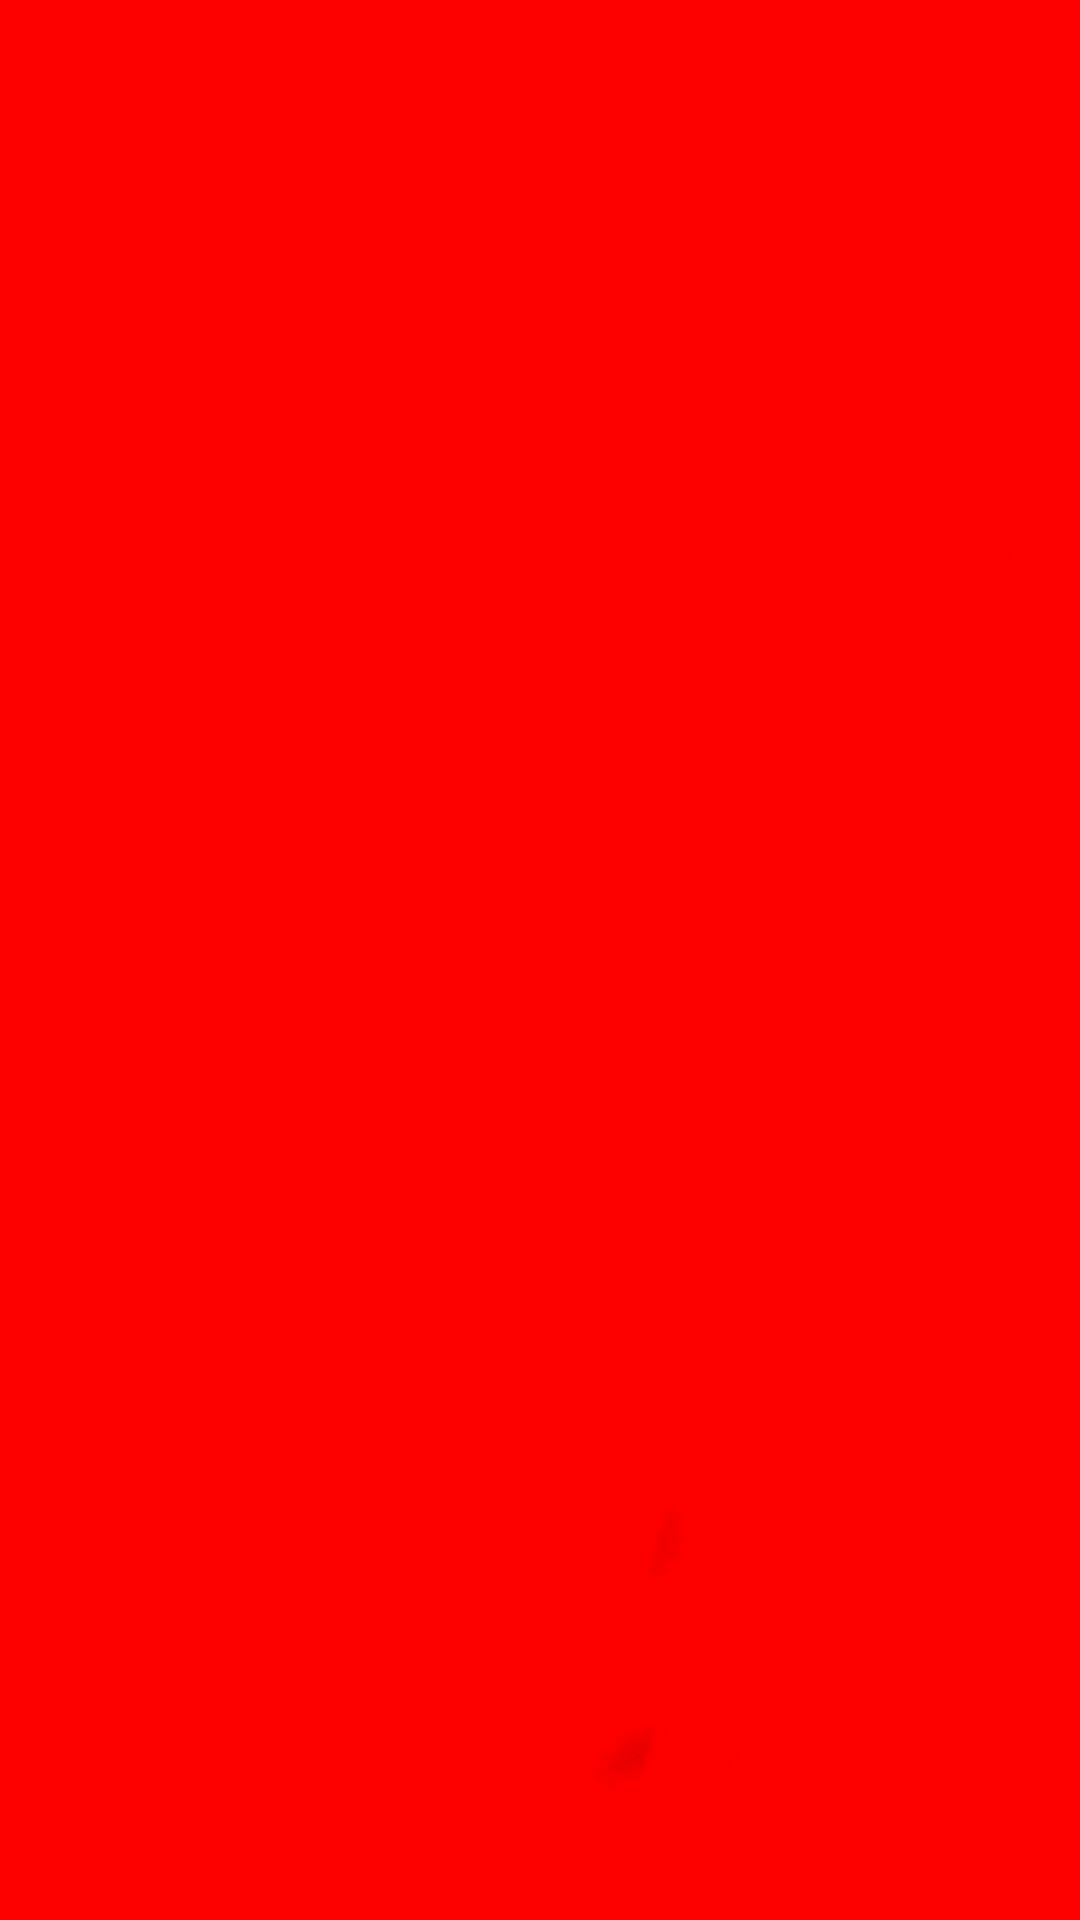

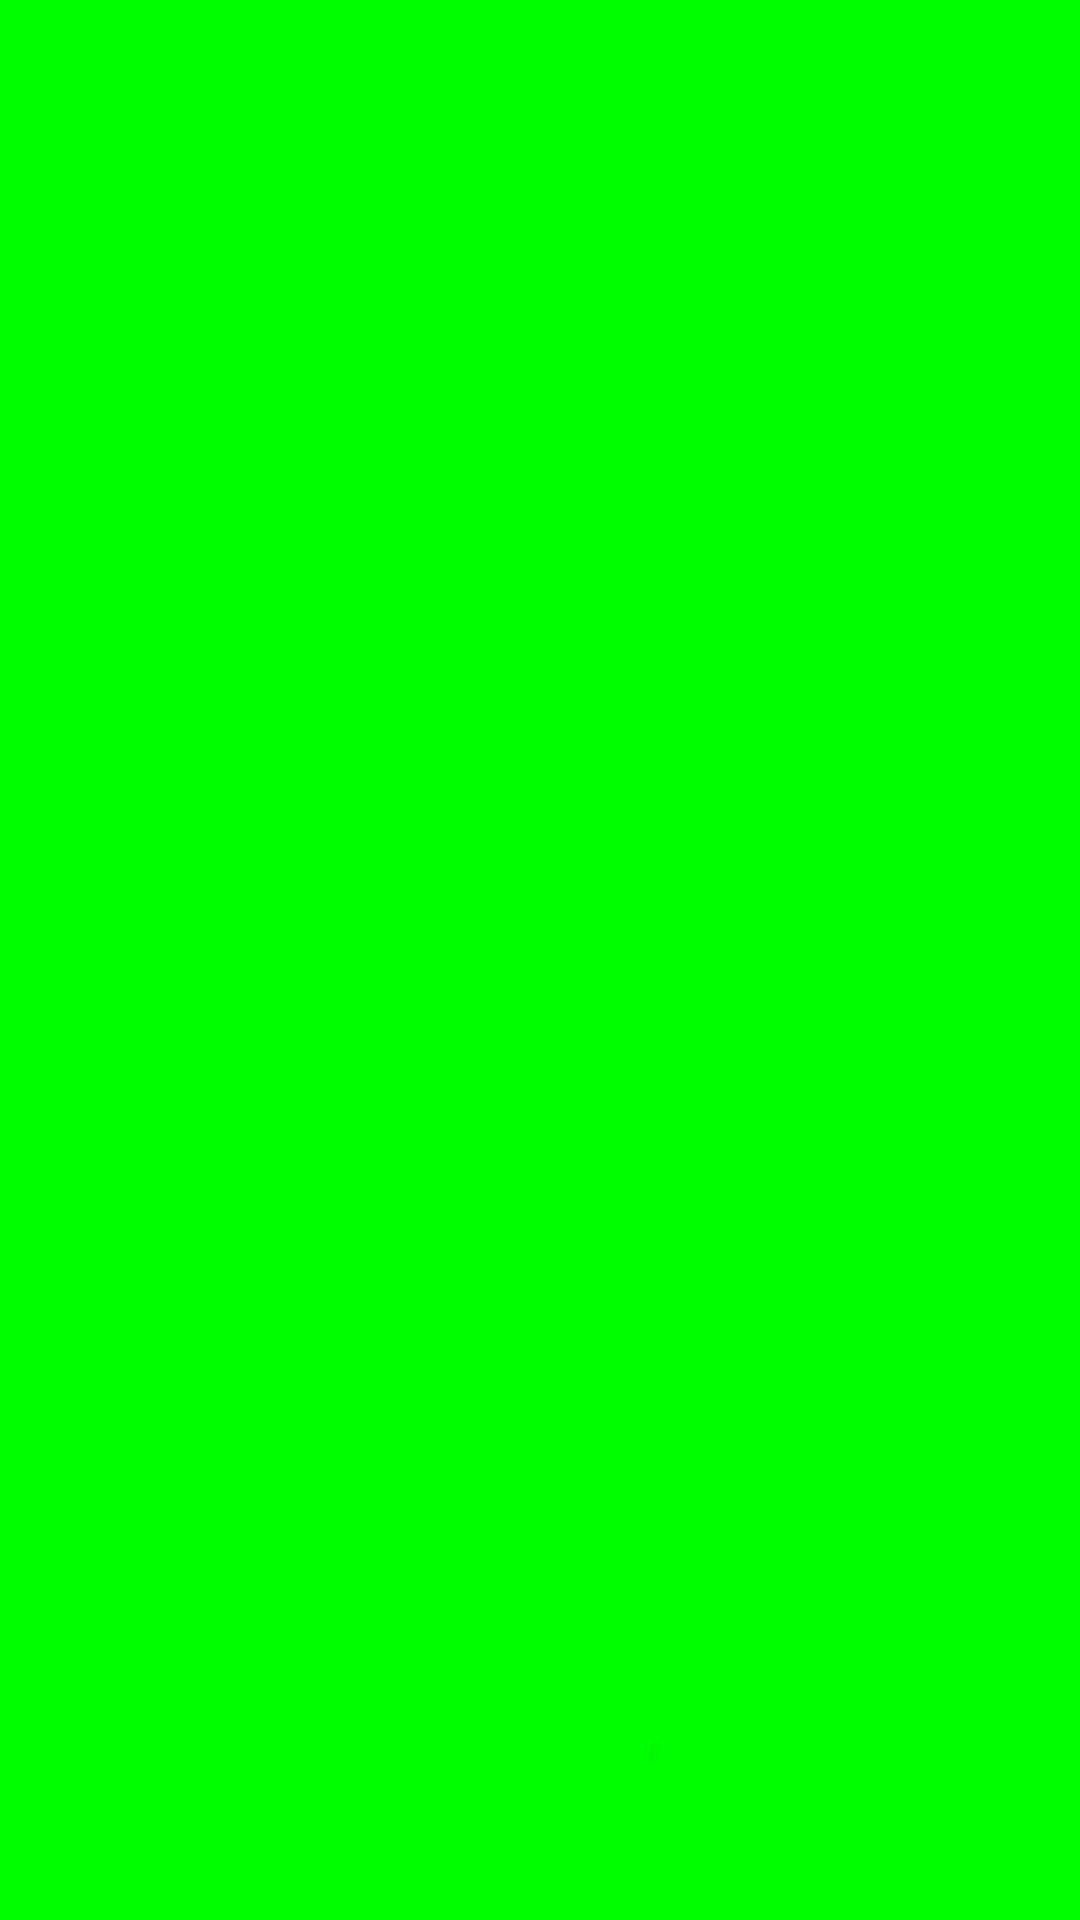

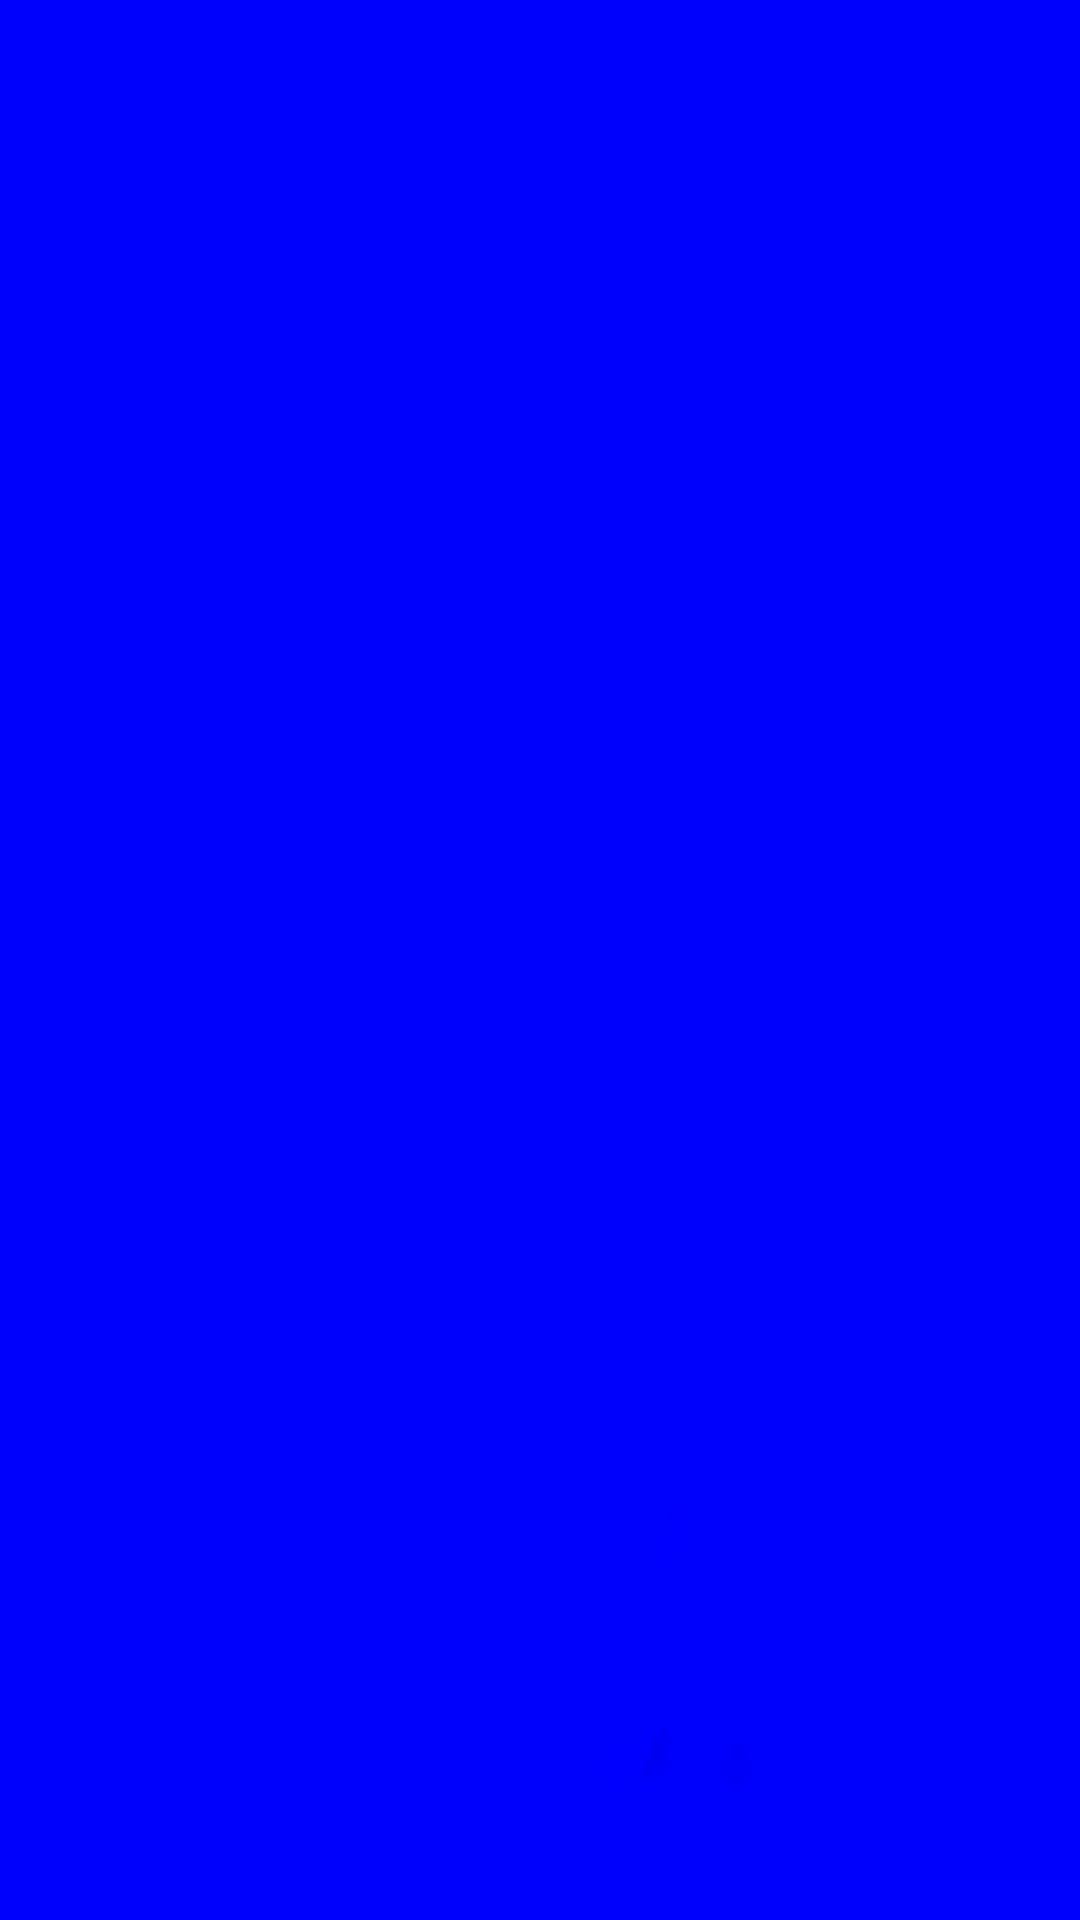

In [8]:
R, G, B = obtener_rgb(str(ruta_imagen))
h, w = R.height, R.width

display(visualizar_canal_color(R, 'R'))
display(visualizar_canal_color(G, 'G'))
display(visualizar_canal_color(B, 'B'))

Verificacion de la llave generada con atractor caotico

In [9]:
key, x0, iteraciones_usadas = generar_llave(R, G, B, verbose=True)

Promedio primera fila: 253.00
Parte entera (iteradas a ignorar): 253
x0 (semilla): 0.253
K (valores a generar): 10
Secuencia completa: [3, 10, 11, 2, 13, 18, 13, 24, 6, 10]
Posición media: 4   Valor central: 13
Valor central en binario: 0b1101   Último bit: 1
Dirección: derecha

LLAVE GENERADA: [18, 13, 24, 6, 10]


### Implementación del algoritmo de difusión

In [10]:
R_b, G_b, B_b = obtener_rgb_como_bloques(R, G, B)

matrices_rotadas = generar_matrices_4x4()

encriptacion = matrices_encriptacion(key, matrices_rotacion=matrices_rotadas)
c_r, c_g, c_b = cifrar_imagen(R_b, G_b, B_b, matrices_finales=encriptacion)

# Reorganizar el canal cifrado a las dimensiones originales
def canal_a_2d(canal_cifrado, h, w):
    return canal_cifrado.flatten().reshape(h, w) 

c_r_2d = canal_a_2d(c_r, h, w)
c_g_2d = canal_a_2d(c_g, h, w)
c_b_2d = canal_a_2d(c_b, h, w)

# Separar cada canal en tres "capas" limpias
r_real, r_imag, r_signos = separar_en_tres_capas(c_r_2d)
g_real, g_imag, g_signos = separar_en_tres_capas(c_g_2d)
b_real, b_imag, b_signos = separar_en_tres_capas(c_b_2d)

cifrado_stack = np.stack([
    r_real, g_real, b_real,       # Magnitudes Reales
    r_imag, g_imag, b_imag,       # Magnitudes Imaginarias
    r_signos, g_signos, b_signos  # Mapas de Signos
], axis=0)

# Visualización
np.set_printoptions(suppress=True, precision=2)
print(cifrado_stack)

[[[ 506.  506.  506. ...  506.  506.  506.]
  [ 506.  506.  506. ...  506.  506.  506.]
  [ 506.  506.  506. ...  506.  506.  506.]
  ...
  [2024. 2024. 2024. ... 2024. 2024. 2024.]
  [2024. 2024. 2024. ... 2024. 2024. 2024.]
  [2024. 2024. 2024. ... 2024. 2024. 2024.]]

 [[ 506.  506.  506. ...  506.  506.  506.]
  [ 506.  506.  506. ...  506.  506.  506.]
  [ 506.  506.  506. ...  506.  506.  506.]
  ...
  [2024. 2024. 2024. ... 2024. 2024. 2024.]
  [2024. 2024. 2024. ... 2024. 2024. 2024.]
  [2024. 2024. 2024. ... 2024. 2024. 2024.]]

 [[ 506.  506.  506. ...  506.  506.  506.]
  [ 506.  506.  506. ...  506.  506.  506.]
  [ 506.  506.  506. ...  506.  506.  506.]
  ...
  [2024. 2024. 2024. ... 2024. 2024. 2024.]
  [2024. 2024. 2024. ... 2024. 2024. 2024.]
  [2024. 2024. 2024. ... 2024. 2024. 2024.]]

 ...

 [[   3.    3.    3. ...    3.    3.    3.]
  [   3.    3.    3. ...    3.    3.    3.]
  [   3.    3.    3. ...    3.    3.    3.]
  ...
  [   0.    0.    0. ...    0.    0.    

## Permutación

### Automatas celulares

In [11]:
def regla_A(p, q, r):   return p          # 240: shift-right
def regla_C(p, q, r):   return r          # 170: shift-left
def regla_B(p, q, r):   return q          # 204: identity
def regla_Ab(p, q, r):  return 1 - p      # 15:  shift-right + complemento
def regla_Cb(p, q, r):  return 1 - r      # 85:  shift-left + complemento
def regla_Bb(p, q, r):  return 1 - q      # 51:  complemento

REGLAS = {
    'A': regla_A, 'C': regla_C, 'B': regla_B,
    'Ab': regla_Ab, 'Cb': regla_Cb, 'Bb': regla_Bb
}

TABLA2 = {
    0:  (['A','A','A','Ab','Ab','A','Ab','Ab'],   ['C','C','Cb','Cb','C','Cb','Cb','C']),
    1:  (['A','Ab','Ab','A','Ab','Ab','A','A'],   ['Cb','Cb','C','Cb','Cb','C','C','C']),
    2:  (['Ab','A','Ab','Ab','A','A','A','Ab'],   ['C','Cb','Cb','C','C','C','Cb','Cb']),
    3:  (['Ab','Ab','A','A','A','Ab','Ab','A'],   ['Cb','C','C','C','Cb','Cb','C','Cb']),
    4:  (['C','C','Cb','C','C','Cb','Cb','Cb'],   ['Ab','A','A','Ab','A','A','Ab','Ab']),
    5:  (['Cb','Cb','C','C','Cb','C','C','Cb'],   ['Ab','Ab','Ab','A','A','Ab','A','A']),
    6:  (['C','Cb','Cb','Cb','C','C','Cb','C'],   ['A','A','Ab','Ab','Ab','A','A','Ab']),
    7:  (['Cb','C','C','Cb','Cb','Cb','C','C'],   ['A','Ab','A','A','Ab','Ab','Ab','A']),
    8:  (['B','B','Bb','B','C','Ab','C','Ab'],    ['B','B','Bb','B','Cb','A','Cb','A']),
    9:  (['Bb','Cb','A','B','Cb','A','B','Bb'],   ['Bb','C','Ab','B','C','Ab','B','Bb']),
    10: (['C','Ab','Bb','Bb','B','C','Ab','B'],   ['Cb','A','Bb','Bb','B','Cb','A','B']),
    11: (['Bb','B','C','Ab','Bb','Bb','C','A'],   ['Bb','B','Cb','A','Bb','Bb','C','A']),
    12: (['Bb','Cb','A','C','A','Bb','Bb','B'],   ['Bb','C','Ab','C','A','Bb','Bb','B']),
    13: (['Bb','B','Bb','Cb','A','C','A','Bb'],   ['Bb','B','Bb','C','Ab','C','A','Bb']),
    14: (['C','A','B','Cb','Ab','B','Bb','Bb'],   ['C','A','B','Cb','Ab','B','Bb','Bb']),
    15: (['B','Bb','Cb','A','Bb','Cb','A','B'],   ['B','Bb','C','Ab','Bb','C','Ab','B']),
}

def evolucionar_bloque(bloque, reglas_8):
    longitud = len(bloque)
    nuevo = np.zeros(longitud, dtype=np.uint8)  # Arreglo para nuevo bloque de 8 bits
    
    for i in range(longitud):
        # Leer los vecinos de la fila original aplicando frontera segun la longitud de la fila
        izq = bloque[(i - 1) % longitud]
        cen = bloque[i]
        der = bloque[(i + 1) % longitud]
        
        # Aplica la regla específica asignada a la posición
        nuevo[i] = REGLAS[reglas_8[i]](izq, cen, der)
        
    return nuevo

def evolucionar_fila(fila_bits, reglas_8):
    r = 8 
    n = len(fila_bits)
    assert n % r == 0, f"La fila debe ser múltiplo de {r} (revisa el padding)"
    
    nueva_fila = np.zeros(n, dtype=np.uint8) # Arreglo para nueva fila
    for inicio in range(0, n, r):
        bloque = fila_bits[inicio:inicio + r]
        nueva_fila[inicio:inicio + r] = evolucionar_bloque(bloque, reglas_8)
        
    return nueva_fila

def generar_indices_reglas(x0, n_filas, iteraciones_ignorar, r=3.99999):
    valores = generar_con_logistico(x0, n_filas, iteraciones_ignorar, r)
    reglas_idx = []
    
    for v in valores:
        # floor(v_i×10^14 )  mod 16
        v_abs = abs(v)
        frac = v_abs - int(v_abs)
        grande = int(frac * 10**14)
        # Ajusta el número al rango de 0 a 15 (índices de reglas)
        reglas_idx.append(grande % 16)
        
    return reglas_idx

def cifrar_canal(filas_bin, reglas_idx):
    # Contenedor para almacenar las filas cifradas
    filas_resultado = []
    
    for fila, idx in zip(filas_bin, reglas_idx):
        # Obtiene las 8 reglas de cifrado correspondientes a ese índice
        reglas_8 = TABLA2[idx][0]
        
        # Evoluciona la fila actual con las reglas de cifrado
        filas_resultado.append(evolucionar_fila(fila, reglas_8))
        
    return filas_resultado

### Conversión binaria

In [ ]:
# Hallar el valor máximo de las matrices reales de los canales R, G y B para determinar el número de bits necesarios
max_val = int(np.max([r_real.max(), g_real.max(), b_real.max()]))
num_bits = max_val.bit_length()

R_int = r_real.astype(int)
G_int = g_real.astype(int)
B_int = b_real.astype(int)

# Transformación de los tres canales a UNA SOLA secuencia de filas binarias,
# intercalando R, G y B por píxel (en vez de tratar cada canal por separado)
def canales_a_filas_binarias(R_int, G_int, B_int, n_bits):
    filas_binarias = []
    h, w = R_int.shape

    for i in range(h):
        lista_bits_por_pixel = []
        for j in range(w):
            # Por cada píxel, se intercalan los bits de R, G y B en ese orden
            lista_bits_por_pixel.append(format(int(R_int[i, j]), f'0{n_bits}b'))
            lista_bits_por_pixel.append(format(int(G_int[i, j]), f'0{n_bits}b'))
            lista_bits_por_pixel.append(format(int(B_int[i, j]), f'0{n_bits}b'))

        # Unir todos los bits de la fila (R, G y B intercalados) en una sola cadena de texto
        cadena_bits = ''.join(lista_bits_por_pixel)

        # Calcular y aplicar el relleno de ceros para que la longitud sea múltiplo de 8
        longitud_actual = len(cadena_bits)
        residuo = longitud_actual % 8

        if residuo != 0:
            cantidad_ceros_extra = 8 - residuo
        else:
            cantidad_ceros_extra = 0

        cadena_bits_final = cadena_bits + ('0' * cantidad_ceros_extra)

        # Convertir la cadena en un arreglo numérico
        arreglo_bits_numericos = []
        for caracter_bit in cadena_bits_final:
            arreglo_bits_numericos.append(int(caracter_bit))
        fila_np = np.array(arreglo_bits_numericos, dtype=np.uint8)
        filas_binarias.append(fila_np)

    return filas_binarias

def filas_a_matrices_rgb(filas, n_bits, w):
    h = len(filas)
    bits_por_pixel = n_bits * 3  # R + G + B intercalados

    R_m = np.zeros((h, w), dtype=np.int64)
    G_m = np.zeros((h, w), dtype=np.int64)
    B_m = np.zeros((h, w), dtype=np.int64)

    for i, fila in enumerate(filas):
        # Descarta el relleno ÚNICAMENTE PARA VISUALIZACIÓN
        util = fila[:w * bits_por_pixel]

        # Reconstruye cada píxel agrupando los bits y separando de nuevo R, G y B
        for j in range(w):
            bloque = util[j*bits_por_pixel:(j+1)*bits_por_pixel]
            r_bits = bloque[0:n_bits]
            g_bits = bloque[n_bits:2*n_bits]
            b_bits = bloque[2*n_bits:3*n_bits]
            R_m[i, j] = int(''.join(str(b) for b in r_bits), 2)
            G_m[i, j] = int(''.join(str(b) for b in g_bits), 2)
            B_m[i, j] = int(''.join(str(b) for b in b_bits), 2)

    return R_m, G_m, B_m

# Una sola secuencia de filas binarias, combinando R, G y B por píxel
filas_RGB = canales_a_filas_binarias(R_int, G_int, B_int, num_bits)

reglas = generar_indices_reglas(x0, h, iteraciones_ignorar=iteraciones_usadas)

# Cifrado: el autómata se aplica una única vez por fila, sobre los bits ya intercalados de R, G y B
filas_RGB_cif = cifrar_canal(filas_RGB, reglas)

# SOLO PARA VISUALIZACIÓN: se separan de nuevo en R, G y B
R_cif_int, G_cif_int, B_cif_int = filas_a_matrices_rgb(filas_RGB_cif, num_bits, w)

print(f"Valor máximo: {max_val}")
print(f"Bits por píxel (por canal): {num_bits}")
print(f"Bits por píxel (R+G+B intercalados): {num_bits * 3}")
print(f"Secuencia de reglas: {reglas}")
print(f"Longitud de la secuencia de reglas: {len(reglas)}")


In [ ]:
# Normalizar los valores de los canales a uint8 para visualización únicamente
def normalizar(arr):
    arr = arr.astype(np.float32)
    mn, mx = arr.min(), arr.max()
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)

with tifffile.TiffWriter(str(ruta_cifrado)) as tif:

    # Página 0: Imagen normalizada y cifrada
    R_vis = normalizar(R_cif_int)
    G_vis = normalizar(G_cif_int)
    B_vis = normalizar(B_cif_int)
    visual_rgb = np.stack([R_vis, G_vis, B_vis], axis=-1)  # Unir los 3 canales
    tif.write(visual_rgb, photometric='rgb')

    # Página 1: Bits cifrados por el autómata, con R, G y B ya intercalados por píxel
    # (una sola página en vez de tres, ya que ahora los tres canales comparten la misma fila de bits)
    arr_bits_rgb = np.array(filas_RGB_cif, dtype=np.uint8)
    tif.write(arr_bits_rgb, photometric='minisblack')

    # Página 2: Parte imaginaria tal como estaba antes, ya que el autómata solo cifra la parte real
    for nombre, capa in [('R', r_imag), ('G', g_imag), ('B', b_imag)]:
        tif.write(capa.astype(np.float32), photometric='minisblack')

    # Página 3: Mapa de signos (tampoco los toca el autómata)
    for nombre, capa in [('R', r_signos), ('G', g_signos), ('B', b_signos)]:
        tif.write(capa.astype(np.float32), photometric='minisblack')

# Imagen a mostrar
pagina0 = tifffile.imread(str(ruta_cifrado), key=0)
display(Image.fromarray(pagina0, mode='RGB'))

# Datos completos que se pasaran junto con la imagen para poder decifrar
# (el relleno ahora depende de num_bits * 3, porque cada píxel aporta R+G+B intercalados)
padding_bits = (-(w * num_bits * 3)) % 8
# Datos mínimos necesarios para el descifrado
with open(str(ruta_meta), "w") as f:
    f.write(f"Llave={key}\n")
    f.write(f"x0={x0}\n")
    f.write(f"iteraciones_usadas={iteraciones_usadas}\n")
